In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import os
from infomap import Infomap
import pandas as pd
import matplotlib as mpl

from collections import defaultdict
from sklearn.metrics import normalized_mutual_info_score, v_measure_score, jaccard_score

In [2]:
# Create ground truth labels for 300 nodes
# Each block of 60 nodes belongs to the same community, resulting in 5 communities total
ground_truth = []
for i in range(300):
    ground_truth.append(i // 60)

In [3]:
def get_predicted_labels(predicted_sets, total_nodes, start_at_one=True):
    #Converts [{1,2}, {3,4}] into a flat list of community IDs.
    labels = [0] * total_nodes
    
    for cluster_id, community_set in enumerate(predicted_sets):
        for node in community_set:
            # If nodes are 1-300, we store them at index 0-299
            node = int(node)  # Ensure node is an integer
            index = node - 1 if start_at_one else node
            # Assign the cluster ID (0, 1, 2...) to that node's position
            labels[index] = cluster_id
    return labels

In [4]:
def infomap_to_networkx_communities(G):
    im = Infomap(silent=True) 
    mapping = im.add_networkx_graph(G)
    im.run()

    infomap_partition = im.get_modules()
    community_dict = defaultdict(set)
    for node, community in infomap_partition.items():
        community_dict[community].add(mapping[node])
    
    return list(community_dict.values())

In [5]:
# Define fixed anchor nodes and their corresponding colors
anchor_nodes = [1, 61, 121, 181, 241]
rainbow_cmap = mpl.cm.get_cmap('gist_ncar', 100)
anchor_to_color = {i: rainbow_cmap(i * 20) for i in range(5)}

def get_colors(communities, G):
    #Map cluster IDs to colors based on anchor node presence
    cluster_to_anchor_color_map = {}
    
    # Associate clusters with specific anchor colors
    for anchor_idx, anchor_node in enumerate(anchor_nodes):
        assigned_cluster_id = None
        for cid, community_set in enumerate(communities):
            if int(anchor_node) in [int(n) for n in community_set]:
                assigned_cluster_id = cid
                break
        
        if assigned_cluster_id is not None:
            cluster_to_anchor_color_map[assigned_cluster_id] = anchor_to_color[anchor_idx]

    # Handle clusters without anchor nodes
    extra_cluster_ids = sorted([cid for cid in range(len(communities)) 
                                if cid not in cluster_to_anchor_color_map])
    
    extra_to_color_map = {
        cid: rainbow_cmap((i * 3 + 5) % 100) 
        for i, cid in enumerate(extra_cluster_ids)
    }
            
    # Generate final color list matching G.nodes() order
    node_colors_final = []
    for node in G.nodes():
        node_id = int(node)
        
        assigned_cluster_id = None
        for cid, community_set in enumerate(communities):
            if node_id in [int(n) for n in community_set]:
                assigned_cluster_id = cid
                break
        
        if assigned_cluster_id is not None:
            color = cluster_to_anchor_color_map.get(
                assigned_cluster_id, 
                extra_to_color_map.get(assigned_cluster_id)
            )
        else:
            color = (0.5, 0.5, 0.5, 0.1) # Default for unassigned nodes
            
        node_colors_final.append(color)
        
    return node_colors_final

/var/folders/mb/bykb8fdj4cx38j5x2fphmv8r0000gp/T/ipykernel_73762/1110127845.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  rainbow_cmap = mpl.cm.get_cmap('gist_ncar', 100)


In [6]:
def analyze_networks(base_path, prr_values, algorithms):
    all_results = []
    
    for algo_name in algorithms:
        print(f"Processing: {algo_name}...")
        for prr in prr_values:
            fmt_prr = f"{prr:.2f}"
            file_name = f"synthetic_network_N_300_blocks_5_prr_{fmt_prr}_prs_0.02.net"
            file_path = os.path.join(base_path, file_name)
            
            if not os.path.exists(file_path): continue
            
            # load and search clusters
            G = nx.Graph(nx.read_pajek(file_path))
            
            if algo_name == 'louvain':
                comm = nx.community.louvain_communities(G, seed=123)
            elif algo_name == 'infomap':
                comm = infomap_to_networkx_communities(G)
            elif algo_name == 'greedy':
                comm = nx.community.greedy_modularity_communities(G)
            
            # metrics
            pred_labels = get_predicted_labels(comm, 300)
            
            res = {
                'algo': algo_name,
                'prr': prr,
                'modularity': nx.community.modularity(G, comm),
                'n_communities': len(comm),
                'nmi': normalized_mutual_info_score(ground_truth, pred_labels, average_method='arithmetic'),
                'jaccard': jaccard_score(ground_truth, pred_labels, average='macro'),
                'nvi': v_measure_score(ground_truth, pred_labels) # NVI
            }
            all_results.append(res)
            
    return pd.DataFrame(all_results)

In [7]:
base_path = "./A3_synthetic_networks/"
prr_values = np.arange(0.00, 1.01, 0.02)
selected_values = [0.02, 0.16, 1.00] 
algorithms = ['louvain', 'infomap', 'greedy'] 

In [8]:
df = analyze_networks(base_path, prr_values, algorithms)

Processing: louvain...
Processing: infomap...
Processing: greedy...


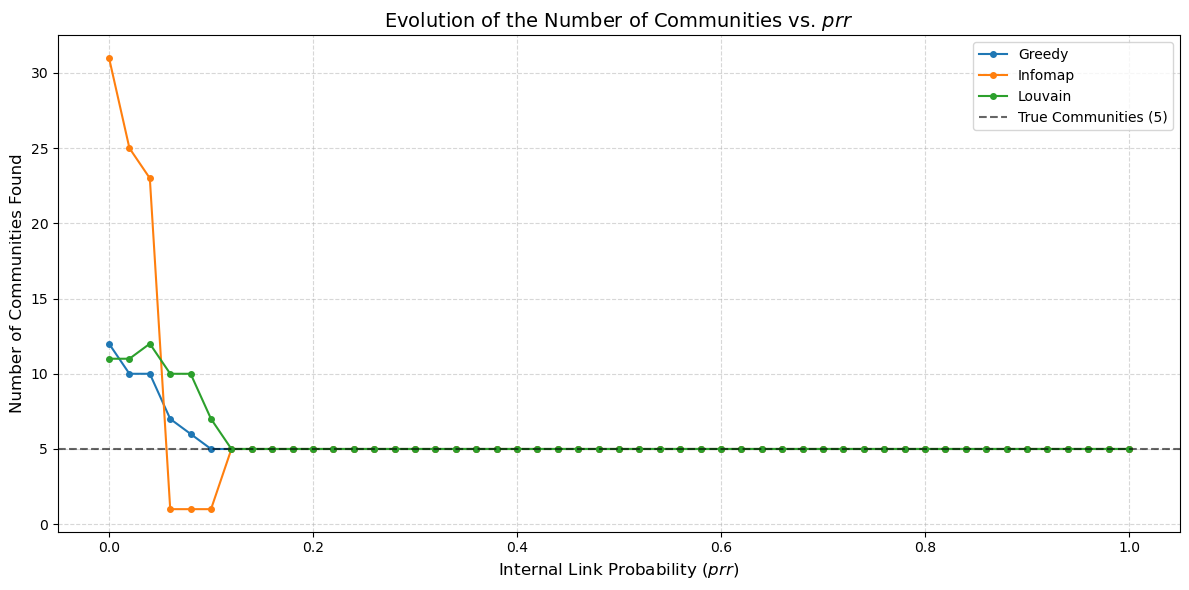

In [9]:
import matplotlib.pyplot as plt

# Sort dataframe to ensure lines are continuous
df_sorted = df.sort_values('prr')

# Plot 1: Number of Communities
plt.figure(figsize=(12, 6)) # Wide format for page width
for algo, group in df_sorted.groupby('algo'):
    plt.plot(group['prr'], group['n_communities'], 
             label=algo.capitalize(), marker='o', markersize=4, linewidth=1.5)

plt.axhline(y=5, color='black', linestyle='--', alpha=0.6, label='True Communities (5)')
plt.title('Evolution of the Number of Communities vs. $prr$', fontsize=14)
plt.xlabel('Internal Link Probability ($prr$)', fontsize=12)
plt.ylabel('Number of Communities Found', fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(loc='best')
plt.tight_layout()
plt.show()

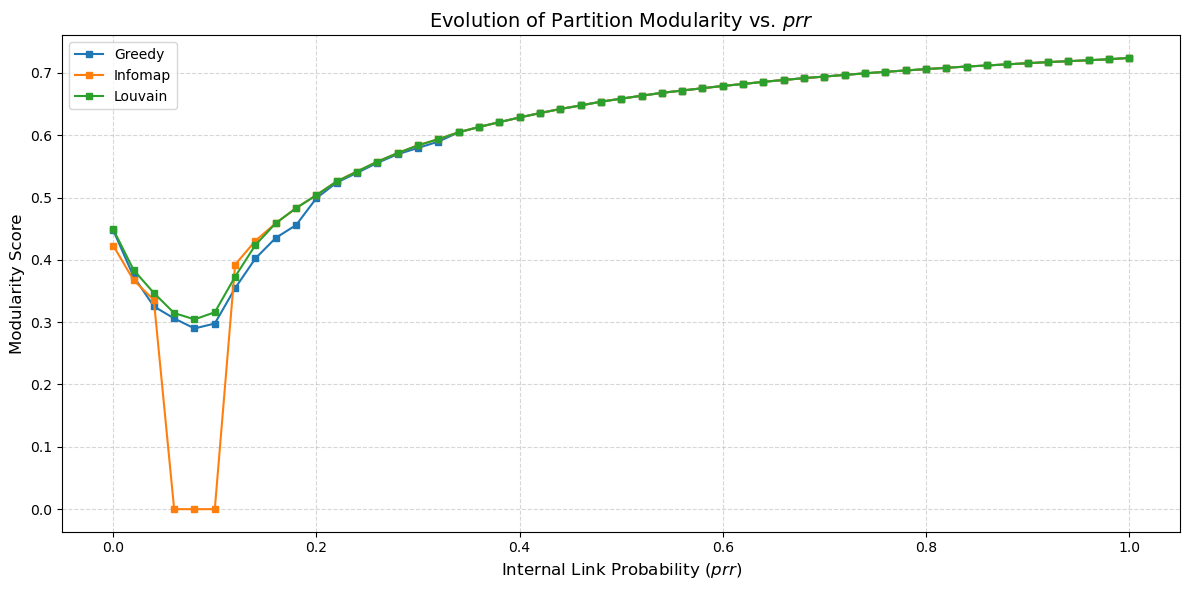

In [10]:
# Plot 2: Modularity
plt.figure(figsize=(12, 6))
for algo, group in df_sorted.groupby('algo'):
    plt.plot(group['prr'], group['modularity'], 
             label=algo.capitalize(), marker='s', markersize=4, linewidth=1.5)

plt.title('Evolution of Partition Modularity vs. $prr$', fontsize=14)
plt.xlabel('Internal Link Probability ($prr$)', fontsize=12)
plt.ylabel('Modularity Score', fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(loc='best')
plt.tight_layout()
plt.show()

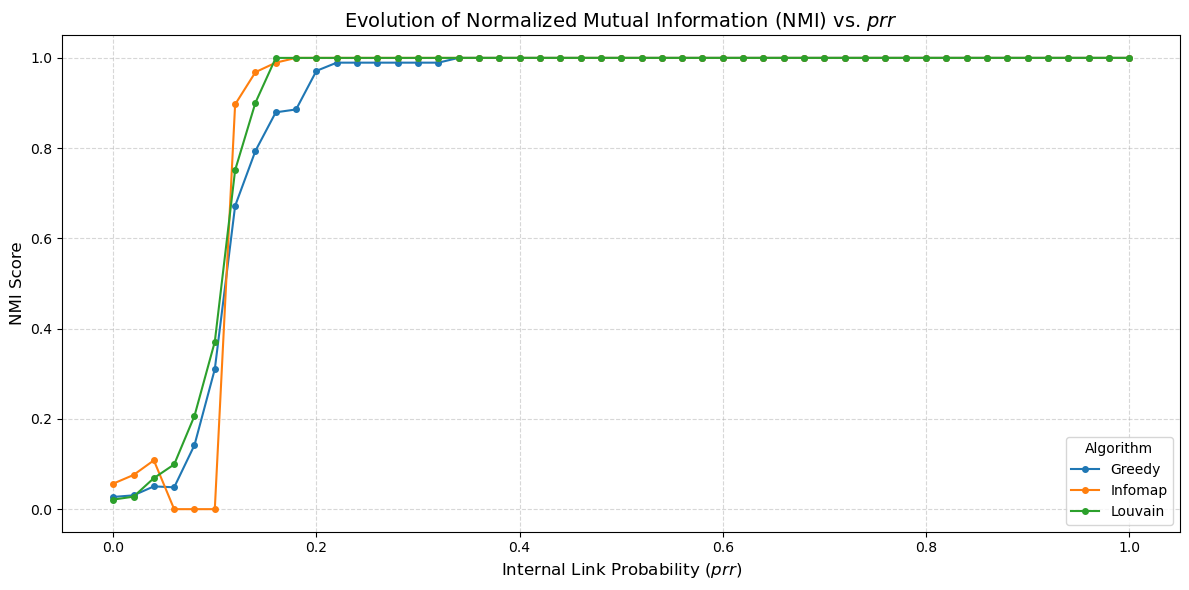

In [11]:
import matplotlib.pyplot as plt

# Define consistent colors to match your previous plots
algo_colors = {'greedy': 'tab:blue', 'infomap': 'tab:orange', 'louvain': 'tab:green'}

# Plot 3a: Normalized Mutual Information (NMI)
plt.figure(figsize=(12, 6))
for algo, group in df_sorted.groupby('algo'):
    plt.plot(group['prr'], group['nmi'], 
             label=f'{algo.capitalize()}', 
             color=algo_colors.get(algo), marker='o', markersize=4)

plt.title('Evolution of Normalized Mutual Information (NMI) vs. $prr$', fontsize=14)
plt.xlabel('Internal Link Probability ($prr$)', fontsize=12)
plt.ylabel('NMI Score', fontsize=12)
plt.ylim(-0.05, 1.05)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title="Algorithm", loc='lower right')
plt.tight_layout()
plt.show()

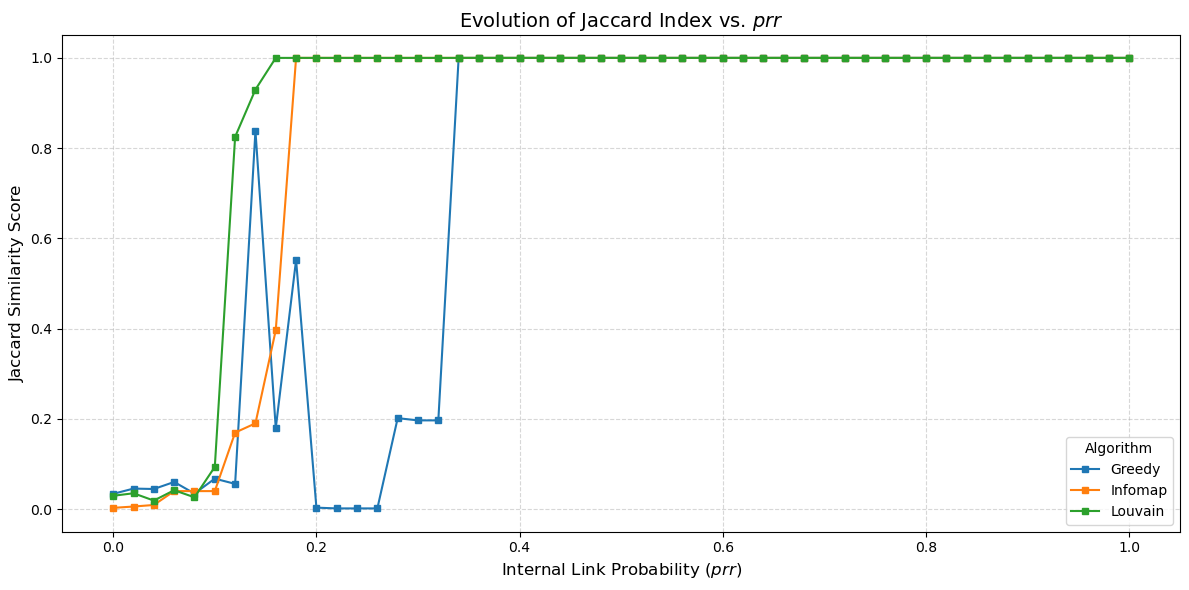

In [12]:
# Plot 3b: Jaccard Index
plt.figure(figsize=(12, 6))
for algo, group in df_sorted.groupby('algo'):
    plt.plot(group['prr'], group['jaccard'], 
             label=f'{algo.capitalize()}', 
             color=algo_colors.get(algo), marker='s', markersize=4)

plt.title('Evolution of Jaccard Index vs. $prr$', fontsize=14)
plt.xlabel('Internal Link Probability ($prr$)', fontsize=12)
plt.ylabel('Jaccard Similarity Score', fontsize=12)
plt.ylim(-0.05, 1.05)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title="Algorithm", loc='lower right')
plt.tight_layout()
plt.show()

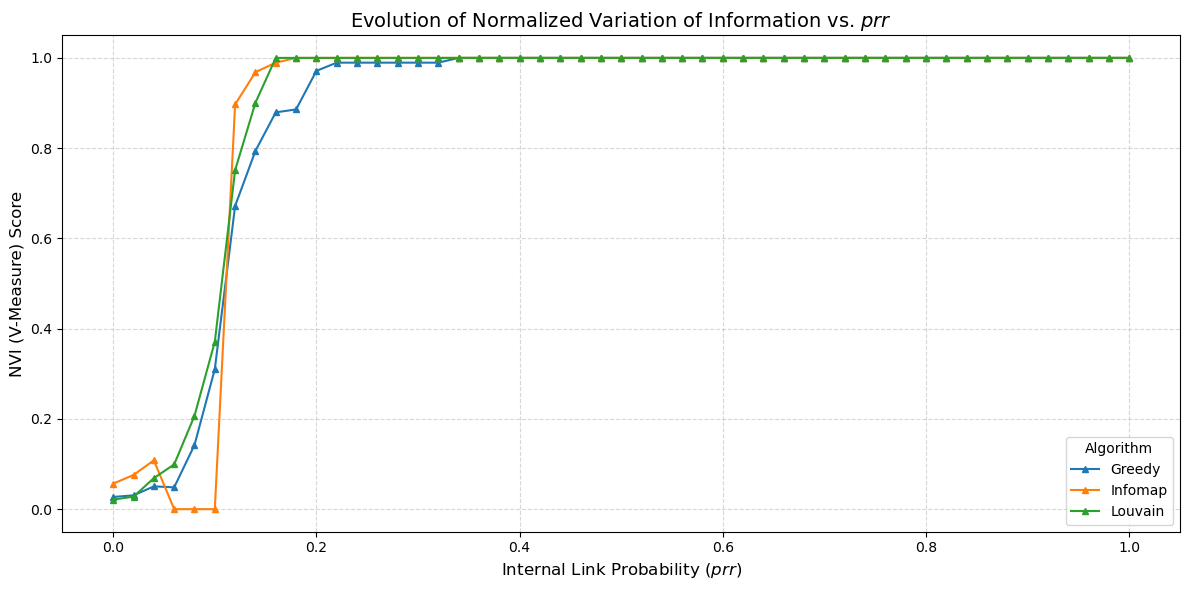

In [13]:
# Plot 3c: Normalized Variation of Information (V-Measure)
plt.figure(figsize=(12, 6))
for algo, group in df_sorted.groupby('algo'):
    plt.plot(group['prr'], group['nvi'], 
             label=f'{algo.capitalize()}', 
             color=algo_colors.get(algo), marker='^', markersize=4)

plt.title('Evolution of Normalized Variation of Information vs. $prr$', fontsize=14)
plt.xlabel('Internal Link Probability ($prr$)', fontsize=12)
plt.ylabel('NVI (V-Measure) Score', fontsize=12)
plt.ylim(-0.05, 1.05)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title="Algorithm", loc='lower right')
plt.tight_layout()
plt.show()

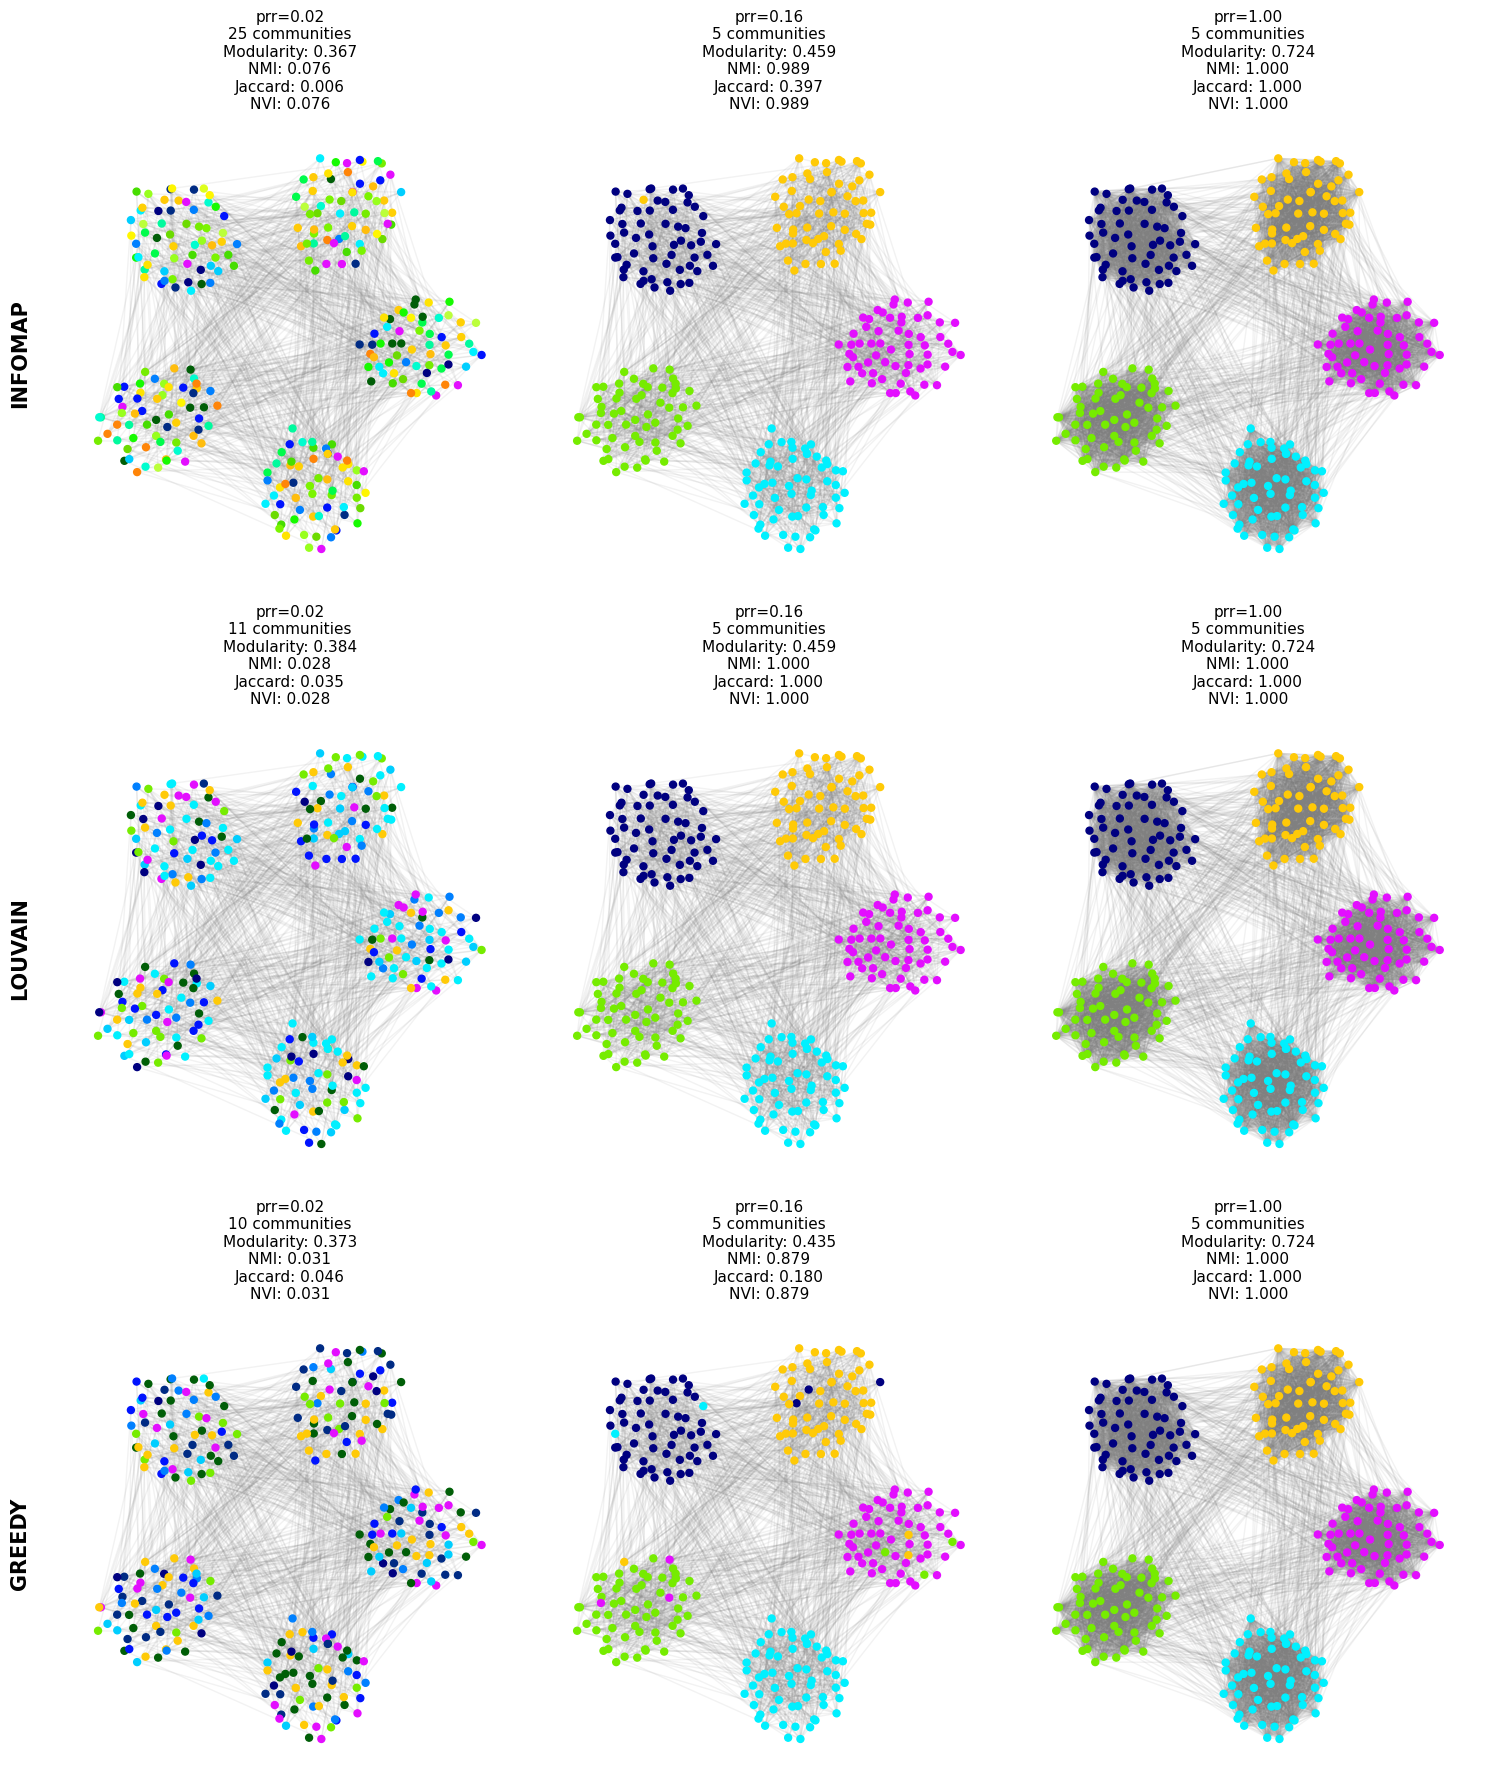

In [14]:
# Configuration
viz_prr = [0.02, 0.16, 1.00]
algorithms = ['infomap', 'louvain', 'greedy']
base_path = "./A3_synthetic_networks/"

# Calculate fixed layout based on the densest network for consistency
ref_file = os.path.join(base_path, "synthetic_network_N_300_blocks_5_prr_1.00_prs_0.02.net")
G_ref = nx.Graph(nx.read_pajek(ref_file))
fixed_pos = nx.fruchterman_reingold_layout(G_ref, seed=42)

# Initialize plot grid
fig, axes = plt.subplots(len(algorithms), len(viz_prr), 
                         figsize=(len(viz_prr) * 5, len(algorithms) * 6))

for row, algo in enumerate(algorithms):
    for col, prr in enumerate(viz_prr):
        ax = axes[row, col]
        
        # Load network file
        fmt_prr = f"{prr:.2f}"
        file_name = f"synthetic_network_N_300_blocks_5_prr_{fmt_prr}_prs_0.02.net"
        file_path = os.path.join(base_path, file_name)
        
        if not os.path.exists(file_path):
            ax.text(0.5, 0.5, f"File Not Found:\n{fmt_prr}", ha='center')
            ax.axis('off')
            continue

        G = nx.Graph(nx.read_pajek(file_path))

        # Run community detection
        if algo == 'louvain':
            communities = nx.community.louvain_communities(G, seed=123)
        elif algo == 'infomap':
            communities = infomap_to_networkx_communities(G) 
        elif algo == 'greedy':
            communities = nx.community.greedy_modularity_communities(G)
        
        # Create flat array of predicted communities for sklearn metrics
        node_to_comm = {node: idx for idx, comm in enumerate(communities) for node in comm}
        communities_flat = [node_to_comm[n] for n in G.nodes()]
        
        # Get ground truth (modify based on your data attributes)
        # ground_truth = [G.nodes[n].get('block', 0) for n in G.nodes()]
        
        # Calculate metrics
        num_communities = len(communities)
        nmi = normalized_mutual_info_score(ground_truth, communities_flat)
        jaccard = jaccard_score(ground_truth, communities_flat, average='macro')
        nvi = v_measure_score(ground_truth, communities_flat)
        modularity = nx.community.modularity(G, communities)

        # Format title text
        title_text = (
            f"prr={fmt_prr}\n"
            f"{num_communities} communities\n"
            f"Modularity: {modularity:.3f}\n"
            f"NMI: {nmi:.3f}\n"
            f"Jaccard: {jaccard:.3f}\n"
            f"NVI: {nvi:.3f}"
        )
        
        # Assign colors and draw (assuming get_colors is defined)
        node_colors = get_colors(communities, G) 

        nx.draw_networkx_edges(G, fixed_pos, ax=ax, alpha=0.1, edge_color='grey')
        nx.draw_networkx_nodes(G, fixed_pos, ax=ax, node_size=25, node_color=node_colors)
        
        # Formatting
        ax.set_title(title_text, fontsize=11, fontweight='normal')
        
        if col == 0:
            ax.set_ylabel(algo.upper(), fontsize=15, fontweight='bold', labelpad=20)
            ax.patch.set_visible(False)
            for spine in ax.spines.values():
                spine.set_visible(False)
            ax.get_xaxis().set_ticks([])
            ax.get_yaxis().set_ticks([])
        else:
            ax.axis('off')

plt.tight_layout()
plt.show()